<a href="https://colab.research.google.com/github/atilimai/plant-ai-project/blob/main/notebooks/Ilgin_Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Aktif Cihaz: {device} 🚀")

Aktif Cihaz: cuda 🚀


In [4]:
import os
import glob
import pandas as pd

if not os.path.exists('PlantVillage-Dataset'):
    print("Orijinal PlantVillage veri seti resmi kaynaktan indiriliyor... ⏳")
    !git clone https://github.com/spMohanty/PlantVillage-Dataset.git
    print("İndirme tamamlandı!")
else:
    print("Veri seti zaten mevcut.")

image_dir = "PlantVillage-Dataset/raw/color"
image_paths = glob.glob(os.path.join(image_dir, "**/*.JPG"), recursive=True) + \
              glob.glob(os.path.join(image_dir, "**/*.jpg"), recursive=True)

if len(image_paths) == 0:
    raise FileNotFoundError("Görseller bulunamadı, lütfen klasör yolunu kontrol edin.")

data_list = []
for p in image_paths:
    folder_name = p.split('/')[-2]

    binary_label = 0 if "healthy" in folder_name.lower() else 1

    data_list.append({'image_path': p, 'binary_label': binary_label, 'folder_name': folder_name})

train_df = pd.DataFrame(data_list)

print("\n================ VERİ SETİ ÖZETİ ================")
print(f"Toplam bulunan görsel sayısı: {len(train_df)}")
print("\n--- Sınıf Dağılımı ---")
print(train_df['binary_label'].value_counts().rename({0: '0 (Sağlıklı)', 1: '1 (Hastalıklı)'}))
print("=================================================\n")

train_df_split = train_df.sample(frac=0.8, random_state=42).reset_index(drop=True)
test_df_split = train_df.drop(train_df_split.index).reset_index(drop=True)

print(f"Eğitim (Train) seti boyutu: {len(train_df_split)}")
print(f"Test (Validation) seti boyutu: {len(test_df_split)}")

Orijinal PlantVillage veri seti resmi kaynaktan indiriliyor... ⏳
Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 17.59 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.
İndirme tamamlandı!

================ VERİ SETİ ÖZETİ ================
Toplam bulunan görsel sayısı: 54303

--- Sınıf Dağılımı ---
binary_label
1 (Hastalıklı)    39220
0 (Sağlıklı)      15083
Name: count, dtype: int64

Eğitim (Train) seti boyutu: 43442
Test (Validation) seti boyutu: 10861


In [5]:
class PlantDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Görsel yolunu al ve yükle
        img_path = self.df.iloc[idx]['image_path']
        image = Image.open(img_path).convert("RGB")

        # İkili etiketi al (0 veya 1)
        label = self.df.iloc[idx]['binary_label']

        if self.transform:
            image = self.transform(image)

        return image, label

# Görsel Dönüşümleri (Transformations)
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset ve DataLoader oluşturma
train_dataset = PlantDataset(train_df_split, transform)
test_dataset = PlantDataset(test_df_split, transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Batch'ler yeni veri yapısına göre başarıyla hazırlandı! 🚀")

Batch'ler yeni veri yapısına göre başarıyla hazırlandı! 🚀


In [6]:
class PlantBaselineModel(nn.Module):
    def __init__(self, num_classes=2):
        super(PlantBaselineModel, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = PlantBaselineModel(num_classes=2).to(device)
print(model)
print("\nModel başarıyla oluşturuldu ve cihaza gönderildi.")

PlantBaselineModel(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

Model başarıyla oluşturuldu ve cihaza gönderildi.


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 3

print("Eğitim başlıyor... 🎯")

for epoch in range(epochs):
    # --- EĞİTİM ADIMI ---
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(x=images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    # --- DOĞRULAMA (VALIDATION) ADIMI ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(test_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")

Eğitim başlıyor... 🎯


Epoch 1/3 [Train]: 100%|██████████| 1358/1358 [01:29<00:00, 15.09it/s]


Epoch [1/3] -> Train Loss: 0.1785 | Val Loss: 0.1208 | Val Accuracy: 95.98%


Epoch 2/3 [Train]: 100%|██████████| 1358/1358 [01:25<00:00, 15.86it/s]


Epoch [2/3] -> Train Loss: 0.0729 | Val Loss: 0.0418 | Val Accuracy: 98.91%


Epoch 3/3 [Train]: 100%|██████████| 1358/1358 [01:20<00:00, 16.78it/s]


Epoch [3/3] -> Train Loss: 0.0435 | Val Loss: 0.0344 | Val Accuracy: 99.06%


In [8]:
os.makedirs('models/checkpoints', exist_ok=True)
os.makedirs('artifacts/figures', exist_ok=True)
os.makedirs('artifacts/reports', exist_ok=True)

model_path = "models/checkpoints/binary_baseline_model.pth"
torch.save(model.state_dict(), model_path)
print(f"Model başarıyla '{model_path}' konumuna kaydedildi! 💾")

Model başarıyla 'models/checkpoints/binary_baseline_model.pth' konumuna kaydedildi! 💾


Test Verisi Değerlendiriliyor: 100%|██████████| 340/340 [00:22<00:00, 15.16it/s]



================ TEST METRİKLERİ ================
Precision : 0.9862
Recall    : 0.9978
F1-Score  : 0.9919



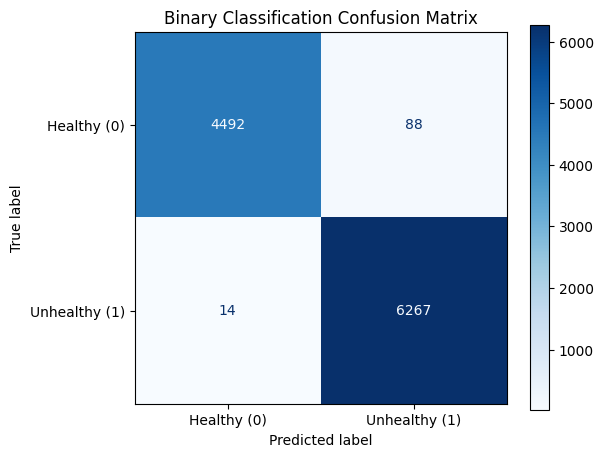

Confusion Matrix grafiği 'artifacts/figures/confusion_matrix.png' olarak kaydedildi! 📊


In [9]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Test Verisi Değerlendiriliyor"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

precision = precision_score(all_labels, all_preds, average='binary')
recall = recall_score(all_labels, all_preds, average='binary')
f1 = f1_score(all_labels, all_preds, average='binary')
cm = confusion_matrix(all_labels, all_preds)

print("\n================ TEST METRİKLERİ ================")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("=================================================\n")

with open("artifacts/reports/binary_classification_report.txt", "w") as f:
    f.write(f"Binary Classification Test Metrics\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1-Score: {f1:.4f}\n")

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy (0)", "Unhealthy (1)"])
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.title("Binary Classification Confusion Matrix")
plt.savefig("artifacts/figures/confusion_matrix.png")
plt.show()

print("Confusion Matrix grafiği 'artifacts/figures/confusion_matrix.png' olarak kaydedildi! 📊")